# Customer Segmentation with K-Means

This notebook performs an end-to-end unsupervised machine learning workflow for customer segmentation.

The objective is to clean customer-level data, engineer useful behavioural features, select relevant variables, identify customer groups with K-Means clustering, and interpret the resulting clusters from a business perspective.

## 1. Imports and project paths

The notebook uses relative paths, so it can run from the GitHub repository without Google Drive or Colab-specific folders.

Expected structure:

```text
customer-segmentation-kmeans/
├── customer_segmentation_kmeans.ipynb
├── data/
│   └── input/
│       └── raw_database.csv
├── reports/
│   ├── raw_database_report.html
│   └── modified_database_report.html
└── outputs/
```

In [23]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "input"
REPORTS_DIR = PROJECT_ROOT / "reports"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True, parents=True)

raw_database_path = DATA_DIR / "raw_database.csv"

print(f"Reading data from: {raw_database_path}")

Reading data from: /content/data/input/raw_database.csv


## 2. Data loading

In [24]:
db_raw = pd.read_csv("/raw_database.csv")

print(f"Rows: {db_raw.shape[0]:,}")
print(f"Columns: {db_raw.shape[1]}")
db_raw.head()

Rows: 404,189
Columns: 12


,customer_id,supply,domestic,direct_debit,tenure_years,num_contracts,num_reminder,num_reminder_soft,num_reminder_hard,num_suspension_request,avg_issue_payment_days,avg_amount
0,1256319262,DUAL,0,0,3.0,6,21,10,11,5.0,82.0,100.0€
1,1083450563,GAS,1,0,12.0,1,5,3,2,NaN,72.0,456.0€
2,1081798459,POWER,1,0,1.0,1,2,2,0,NaN,41.0,88.0€
3,1602025867,POWER,1,0,5.0,1,3,3,0,NaN,51.0,88.0€
4,1319739584,DUAL,0,0,18.0,6,3,0,3,2.0,78.0,240.0€


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Initial data understanding

The dataset contains customer-level information such as supply type, payment behaviour, number of reminders, suspension requests, tenure, contracts and average bill/payment-related variables.

In [25]:
db_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404189 entries, 0 to 404188
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             404189 non-null  int64  
 1   supply                  404189 non-null  object 
 2   domestic                404189 non-null  int64  
 3   direct_debit            404189 non-null  int64  
 4   tenure_years            404189 non-null  float64
 5   num_contracts           404189 non-null  int64  
 6   num_reminder            404189 non-null  int64  
 7   num_reminder_soft       404189 non-null  int64  
 8   num_reminder_hard       404189 non-null  int64  
 9   num_suspension_request  69278 non-null   float64
 10  avg_issue_payment_days  404189 non-null  float64
 11  avg_amount              404189 non-null  object 
dtypes: float64(3), int64(7), object(2)
memory usage: 37.0+ MB


In [26]:
missing_summary = (
    db_raw.isna()
    .sum()
    .to_frame("missing_values")
    .assign(missing_pct=lambda x: 100 * x["missing_values"] / len(db_raw))
    .sort_values("missing_values", ascending=False)
)

missing_summary

,missing_values,missing_pct
num_suspension_request,334911,82.859999
customer_id,0,0.000000
domestic,0,0.000000
supply,0,0.000000
direct_debit,0,0.000000
tenure_years,0,0.000000
num_reminder,0,0.000000
num_contracts,0,0.000000
num_reminder_soft,0,0.000000
num_reminder_hard,0,0.000000


In [27]:
db_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,404189.0,NaN,NaN,NaN,1550149583.102734,317368230.560513,1000000033.0,1275723486.0,1549836420.0,1824457314.0,2099984419.0
supply,404189,3,DUAL,200981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
domestic,404189.0,NaN,NaN,NaN,0.890591,0.312152,0.0,1.0,1.0,1.0,1.0
direct_debit,404189.0,NaN,NaN,NaN,0.167046,0.373017,0.0,0.0,0.0,0.0,1.0
tenure_years,404189.0,NaN,NaN,NaN,7.165729,6.086622,0.0,3.0,5.0,9.0,25.0
num_contracts,404189.0,NaN,NaN,NaN,2.04342,1.241016,1.0,1.0,2.0,2.0,6.0
num_reminder,404189.0,NaN,NaN,NaN,4.182222,4.855901,0.0,1.0,2.0,6.0,21.0
num_reminder_soft,404189.0,NaN,NaN,NaN,2.114724,2.646702,0.0,0.0,1.0,3.0,10.0
num_reminder_hard,404189.0,NaN,NaN,NaN,2.067498,2.922656,0.0,0.0,1.0,3.0,11.0
num_suspension_request,69278.0,NaN,NaN,NaN,2.643927,1.564407,1.0,1.0,2.0,4.0,5.0


## 4. Data cleaning

The cleaning steps are designed to make the dataset suitable for clustering:

- missing suspension requests are interpreted as zero suspension requests;
- the euro symbol is removed from `avg_amount`;
- monetary and numerical columns are converted to numeric values;
- negative values in naturally non-negative fields are replaced with zero;
- the categorical `supply` variable is one-hot encoded.

In [28]:
db_clean = db_raw.copy()

# Missing values: if no suspension request is recorded, treat it as zero
db_clean["num_suspension_request"] = db_clean["num_suspension_request"].fillna(0).astype(int)

# Convert amount from strings such as "100.0€" to numeric values
db_clean["avg_amount"] = (
    db_clean["avg_amount"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
)

db_clean["avg_amount"] = pd.to_numeric(db_clean["avg_amount"], errors="coerce").fillna(0)

# Replace negative values in fields that should be non-negative
non_negative_cols = [
    "tenure_years",
    "num_contracts",
    "num_reminder",
    "num_reminder_soft",
    "num_reminder_hard",
    "num_suspension_request",
    "avg_issue_payment_days",
    "avg_amount",
]

for col in non_negative_cols:
    db_clean[col] = db_clean[col].clip(lower=0)

# One-hot encode supply type
db_clean = pd.get_dummies(db_clean, columns=["supply"], prefix="supply", dtype=int)

db_clean.head()

,customer_id,domestic,direct_debit,tenure_years,num_contracts,num_reminder,num_reminder_soft,num_reminder_hard,num_suspension_request,avg_issue_payment_days,avg_amount,supply_DUAL,supply_GAS,supply_POWER
0,1256319262,0,0,3.0,6,21,10,11,5,82.0,100.0,1,0,0
1,1083450563,1,0,12.0,1,5,3,2,0,72.0,456.0,0,1,0
2,1081798459,1,0,1.0,1,2,2,0,0,41.0,88.0,0,0,1
3,1602025867,1,0,5.0,1,3,3,0,0,51.0,88.0,0,0,1
4,1319739584,0,0,18.0,6,3,0,3,2,78.0,240.0,1,0,0


## 5. Feature engineering

`num_reminders_year` normalises the number of reminders by customer tenure. This makes customers with different relationship lengths more comparable.

In [29]:
db_clean["num_reminders_year"] = (
    db_clean["num_reminder_soft"] + db_clean["num_reminder_hard"]
) / (db_clean["tenure_years"] + 1)

# num_reminder is the sum of soft and hard reminders, so it is removed to avoid duplication.
db_model = db_clean.drop(columns=["num_reminder"])

db_model.head()

,customer_id,domestic,direct_debit,tenure_years,num_contracts,num_reminder_soft,num_reminder_hard,num_suspension_request,avg_issue_payment_days,avg_amount,supply_DUAL,supply_GAS,supply_POWER,num_reminders_year
0,1256319262,0,0,3.0,6,10,11,5,82.0,100.0,1,0,0,5.250000
1,1083450563,1,0,12.0,1,3,2,0,72.0,456.0,0,1,0,0.384615
2,1081798459,1,0,1.0,1,2,0,0,41.0,88.0,0,0,1,1.000000
3,1602025867,1,0,5.0,1,3,0,0,51.0,88.0,0,0,1,0.500000
4,1319739584,0,0,18.0,6,0,3,2,78.0,240.0,1,0,0,0.157895


## 6. Feature selection and scaling

K-Means is distance-based, so variables must be standardised before clustering.

In [30]:
features = [
    "num_contracts",
    "num_suspension_request",
    "avg_issue_payment_days",
    "tenure_years",
    "num_reminders_year",
    "avg_amount",
    "direct_debit",
    "domestic",
    "supply_DUAL",
    "supply_GAS",
    "supply_POWER",
]

X = db_model[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,num_contracts,num_suspension_request,avg_issue_payment_days,tenure_years,num_reminders_year,avg_amount,direct_debit,domestic,supply_DUAL,supply_GAS,supply_POWER
0,6,5,82.0,3.0,5.250000,100.0,0,0,1,0,0
1,1,0,72.0,12.0,0.384615,456.0,0,1,0,1,0
2,1,0,41.0,1.0,1.000000,88.0,0,1,0,0,1
3,1,0,51.0,5.0,0.500000,88.0,0,1,0,0,1
4,6,2,78.0,18.0,0.157895,240.0,0,0,1,0,0


## 7. Model selection: elbow method and silhouette score

To keep the notebook efficient on GitHub, the model-selection step uses a reproducible sample of the dataset. The final clustering model is then fitted on the full dataset.

In [31]:
sample_size = min(50000, len(X_scaled))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        batch_size=4096
    )
    labels_sample = model.fit_predict(X_sample)
    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_sample, labels_sample, sample_size=min(10000, sample_size), random_state=RANDOM_STATE)
    )

model_selection = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

model_selection

,k,inertia,silhouette_score
0,2,456385.694693,0.207943
1,3,363161.548063,0.302358
2,4,312020.410296,0.321848
3,5,293516.684258,0.289234
4,6,279282.127007,0.324969
5,7,262974.143471,0.243288
6,8,233098.652655,0.282071


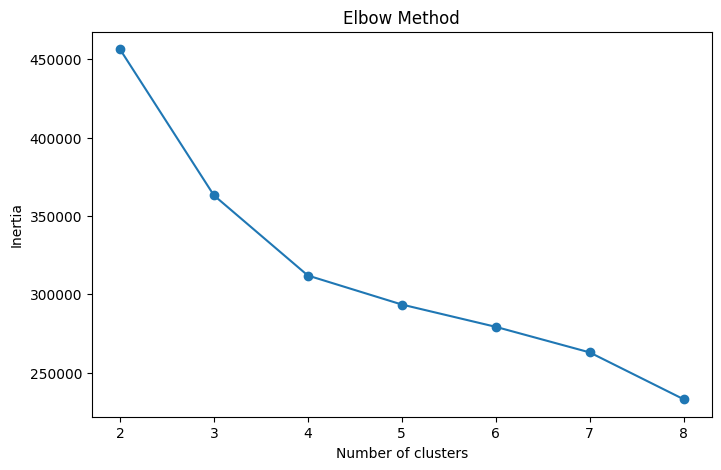

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(model_selection["k"], model_selection["inertia"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

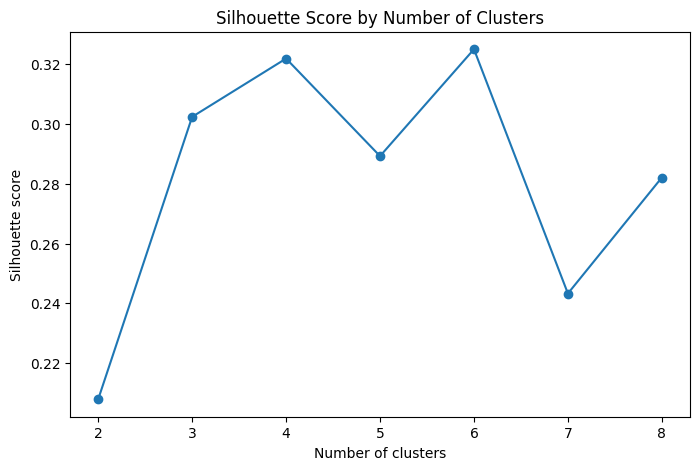

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(model_selection["k"], model_selection["silhouette_score"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

## 8. Final K-Means model

The final number of clusters is set to 4. This keeps the segmentation interpretable while still separating customers by relevant behavioural patterns.

You can change `FINAL_K` after reviewing the elbow and silhouette charts.

In [34]:
FINAL_K = 4

final_model = MiniBatchKMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10,
    batch_size=4096
)

db_final = db_model.copy()
db_final["cluster"] = final_model.fit_predict(X_scaled)

db_final[["customer_id", "cluster"]].head()

,customer_id,cluster
0,1256319262,2
1,1083450563,3
2,1081798459,0
3,1602025867,0
4,1319739584,1


## 9. Cluster profiling

The table below shows the average characteristics of each cluster. This is the main step for translating the mathematical clustering output into business insights.

In [35]:
cluster_profile = (
    db_final
    .drop(columns=["customer_id"])
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_size = (
    db_final["cluster"]
    .value_counts(normalize=False)
    .sort_index()
    .to_frame("customers")
)

cluster_share = (
    db_final["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("share_pct")
)

cluster_summary = cluster_size.join(cluster_share).join(cluster_profile)
cluster_summary

,customers,share_pct,domestic,direct_debit,tenure_years,num_contracts,num_reminder_soft,num_reminder_hard,num_suspension_request,avg_issue_payment_days,avg_amount,supply_DUAL,supply_GAS,supply_POWER,num_reminders_year
cluster,,,,,,,,,,,,,,,
0,85933,21.26,0.77,0.19,4.01,1.26,1.99,1.48,0.16,51.62,197.66,0.00,0.00,1.00,0.92
1,170760,42.25,0.94,0.16,6.99,2.81,1.80,1.66,0.13,48.03,279.50,1.00,0.00,0.00,0.58
2,40998,10.14,0.84,0.06,5.48,2.67,5.27,7.63,3.33,86.33,297.54,0.74,0.11,0.15,2.70
3,106498,26.35,0.93,0.20,10.64,1.20,1.51,1.05,0.11,50.15,190.39,0.00,1.00,0.00,0.40


In [36]:
key_profile_cols = [
    "customers", "share_pct", "num_contracts", "num_suspension_request",
    "avg_issue_payment_days", "tenure_years", "num_reminders_year",
    "avg_amount", "direct_debit", "domestic"
]

cluster_summary[key_profile_cols]

,customers,share_pct,num_contracts,num_suspension_request,avg_issue_payment_days,tenure_years,num_reminders_year,avg_amount,direct_debit,domestic
cluster,,,,,,,,,,
0,85933,21.26,1.26,0.16,51.62,4.01,0.92,197.66,0.19,0.77
1,170760,42.25,2.81,0.13,48.03,6.99,0.58,279.50,0.16,0.94
2,40998,10.14,2.67,3.33,86.33,5.48,2.70,297.54,0.06,0.84
3,106498,26.35,1.20,0.11,50.15,10.64,0.40,190.39,0.20,0.93


## 10. Business interpretation

The following function creates a simple rule-based interpretation of each cluster. It is not meant to replace business judgement, but it helps make the segmentation readable.

In [37]:
def describe_cluster(row):
    notes = []

    if row["num_suspension_request"] >= cluster_summary["num_suspension_request"].quantile(0.75):
        notes.append("high suspension-request behaviour")
    elif row["num_suspension_request"] <= cluster_summary["num_suspension_request"].quantile(0.25):
        notes.append("low suspension-request behaviour")

    if row["num_reminders_year"] >= cluster_summary["num_reminders_year"].quantile(0.75):
        notes.append("frequent reminders per year")
    elif row["num_reminders_year"] <= cluster_summary["num_reminders_year"].quantile(0.25):
        notes.append("limited reminder activity")

    if row["avg_issue_payment_days"] >= cluster_summary["avg_issue_payment_days"].quantile(0.75):
        notes.append("slower payment behaviour")
    elif row["avg_issue_payment_days"] <= cluster_summary["avg_issue_payment_days"].quantile(0.25):
        notes.append("faster payment behaviour")

    if row["avg_amount"] >= cluster_summary["avg_amount"].quantile(0.75):
        notes.append("higher average bill amount")
    elif row["avg_amount"] <= cluster_summary["avg_amount"].quantile(0.25):
        notes.append("lower average bill amount")

    return "; ".join(notes)

business_interpretation = cluster_summary.copy()
business_interpretation["interpretation"] = business_interpretation.apply(describe_cluster, axis=1)

business_interpretation[["customers", "share_pct", "interpretation"]]

,customers,share_pct,interpretation
cluster,,,
0,85933,21.26,
1,170760,42.25,faster payment behaviour
2,40998,10.14,high suspension-request behaviour; frequent re...
3,106498,26.35,low suspension-request behaviour; limited remi...


## 11. Export results

The notebook exports:

- a customer-level file with cluster labels;
- a cluster summary table.

In [38]:
customer_clusters_path = OUTPUTS_DIR / "customer_clusters.csv"
cluster_summary_path = OUTPUTS_DIR / "cluster_summary.csv"

db_final[["customer_id", "cluster"]].to_csv(customer_clusters_path, index=False)
cluster_summary.to_csv(cluster_summary_path)

print(f"Saved customer clusters to: {customer_clusters_path}")
print(f"Saved cluster summary to: {cluster_summary_path}")

Saved customer clusters to: /content/outputs/customer_clusters.csv
Saved cluster summary to: /content/outputs/cluster_summary.csv


## 12. Conclusion

This project provides a complete unsupervised learning workflow for customer segmentation:

1. data loading and inspection;
2. cleaning of missing, categorical and inconsistent values;
3. feature engineering;
4. feature scaling;
5. K-Means clustering;
6. model-selection support through elbow and silhouette analysis;
7. business-oriented cluster interpretation;
8. export of reusable outputs.

The resulting segmentation can support customer monitoring, payment behaviour analysis and targeted business actions.